# Sample Characterization v2 (Tmag < 10)

Selects TIC stars with `plx > 10 mas` and `Tmag < 10` from pre-fetched batch CSVs (no MAST queries).
Produces `processed/df_final.csv` (ID column only).

## Section 0 — Imports & config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lightkurve as lk

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

T              = 1024
STRIDE         = 1024
GAP_THRESHOLD  = 1        # days
NAN_THRESHOLD  = 0.10
CADENCE_DAYS   = 2 / 1440  # TESS 2-min in days

# Locate project root (contains CLAUDE.md)
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.parent != PROJECT_ROOT and not (PROJECT_ROOT / 'CLAUDE.md').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'CLAUDE.md').exists():
    raise FileNotFoundError('Cannot find project root (CLAUDE.md not found)')
PROCESSED = PROJECT_ROOT / 'processed'
print(f'Project root: {PROJECT_ROOT}')

Project root: c:\git_repo\Stellar-World-Model


## Section 1 — Load batch CSVs & apply cuts

In [2]:
batch_files = [
    PROCESSED / 'tic_candidates_batch_0_7.csv',
    PROCESSED / 'tic_candidates_batch_7_8.csv',
    PROCESSED / 'tic_candidates_batch_8_9.csv',
    PROCESSED / 'tic_candidates_batch_9_10.csv',
]

df_raw = pd.concat([pd.read_csv(f) for f in batch_files], ignore_index=True)
print(f'Combined rows: {len(df_raw):,}  |  columns: {list(df_raw.columns)}')

current = df_raw.copy()
print(f'\nInitial: {len(current):,} stars')

prev = len(current)
current = current[current['plx'] > 10].copy()
print(f'After plx > 10 mas: {len(current):,}  (dropped {prev - len(current):,})')

prev = len(current)
current = current[current['Tmag'] < 10].copy()
print(f'After Tmag < 10:    {len(current):,}  (dropped {prev - len(current):,})')

df_work  = current.reset_index(drop=True)   # retains all columns for plots
df_final = df_work[['ID']].copy()           # export: ID only
print(f'\ndf_final: {len(df_final):,} stars')

Combined rows: 594,689  |  columns: ['ID', 'Tmag', 'Teff', 'logg', 'plx', 'rad', 'mass']

Initial: 594,689 stars
After plx > 10 mas: 41,222  (dropped 553,467)
After Tmag < 10:    41,221  (dropped 1)

df_final: 41,221 stars


## Section 2 — `plot_window` utility

Call `plot_window(star_idx, sector_idx=0, window_idx=0)` to inspect any star's light curve and window boundaries. Uses `df_work` (all columns retained).

In [3]:
def _regrid(time_arr: np.ndarray, flux_arr: np.ndarray):
    """Map observations onto a uniform 2-min grid; gaps become NaN."""
    t0      = time_arr[0]
    indices = np.round((time_arr - t0) / CADENCE_DAYS).astype(int)
    n_grid  = indices[-1] + 1
    t_grid  = t0 + np.arange(n_grid) * CADENCE_DAYS
    f_grid  = np.full(n_grid, np.nan)
    f_grid[indices] = flux_arr
    return t_grid, f_grid


def plot_window(star_idx: int, sector_idx: int = 0, window_idx: int = 0) -> None:
    row    = df_work.iloc[star_idx]
    tic_id = int(row['ID'])
    tmag   = row['Tmag']
    teff   = row['Teff'] if not pd.isna(row['Teff']) else float('nan')
    logg   = row['logg'] if not pd.isna(row['logg']) else float('nan')
    print(f'Star #{star_idx}: TIC {tic_id}  Tmag={tmag:.2f}  Teff={teff:.0f} K  logg={logg:.2f}')

    sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author='SPOC', exptime=120)
    if len(sr) == 0:
        print('No SPOC 2-min data found.')
        return

    sectors    = list(sr.table['sequence_number'])
    sector_idx = min(sector_idx, len(sr) - 1)
    print(f'Available sectors ({len(sectors)}): {sectors}')
    print(f'Using sector index {sector_idx} → Sector {sectors[sector_idx]}')

    lc       = sr[sector_idx].download(quality_bitmask='none')
    raw_flux = lc['pdcsap_flux'].value.astype(float)
    raw_time = lc.time.value

    time_grid, flux_grid = _regrid(raw_time, raw_flux)
    n_grid  = len(flux_grid)
    n_nan   = int(np.isnan(flux_grid).sum())
    nan_pct = 100 * n_nan / n_grid

    print(f'\n── Sector {sectors[sector_idx]} NaN summary')
    print(f'  Downloaded cadences : {len(raw_flux)}')
    print(f'  Uniform grid points : {n_grid}')
    print(f'  NaN (gaps)          : {n_nan} / {n_grid}  ({nan_pct:.2f}%)')

    starts     = list(range(0, n_grid - T + 1, STRIDE))
    nan_counts = [int(np.isnan(flux_grid[s:s + T]).sum()) for s in starts]
    n_pass     = sum(1 for c in nan_counts if c / T < NAN_THRESHOLD)
    print(f'\n── Window breakdown (T={T}, stride={STRIDE})')
    print(f'  Total windows : {len(starts)}')
    print(f'  Pass NaN<10%  : {n_pass} / {len(starts)}')
    for wi, (s, nc) in enumerate(zip(starts, nan_counts)):
        marker = ' ✓' if nc / T < NAN_THRESHOLD else ' ✗'
        sel    = ' ← selected' if wi == min(window_idx, len(starts) - 1) else ''
        print(f'    [{wi:>3}] cadences [{s:>5}, {s+T:>5})  NaN={nc:>4}/{T}  ({100*nc/T:>5.1f}%){marker}{sel}')

    window_idx = min(window_idx, len(starts) - 1)
    s          = starts[window_idx]
    win_flux   = flux_grid[s:s + T]
    win_time   = time_grid[s:s + T]
    nan_count  = nan_counts[window_idx]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].plot(time_grid, flux_grid, lw=0.5, color='steelblue', alpha=0.8)
    axes[0].axvspan(win_time[0], win_time[-1], color='orange', alpha=0.30, label=f'Window {window_idx}')
    axes[0].set_title(
        f'TIC {tic_id} — Sector {sectors[sector_idx]} (uniform grid)  |  '
        f'NaN: {n_nan}/{n_grid} ({nan_pct:.1f}%)', fontsize=12)
    axes[0].set_ylabel('PDCSAP Flux')
    axes[0].legend(fontsize=10)

    axes[1].plot(win_time, win_flux, lw=0.8, color='darkorange', marker='.', ms=2)
    axes[1].set_title(
        f'Window {window_idx}  |  grid pts [{s}, {s+T})  |  '
        f'NaN: {nan_count}/{T} ({100*nan_count/T:.1f}%)', fontsize=12)
    axes[1].set_xlabel('Time (BTJD)')
    axes[1].set_ylabel('PDCSAP Flux')

    plt.suptitle(
        f'TIC {tic_id}  Tmag={tmag:.2f}  Teff={teff:.0f} K  logg={logg:.2f}',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Star #20: TIC 372131402  Tmag=5.48  Teff=5669 K  logg=3.86
Available sectors (3): [np.int64(17), np.int64(57), np.int64(84)]
Using sector index 0 → Sector 17

── Sector 17 NaN summary
  Downloaded cadences : 16982
  Uniform grid points : 18012
  NaN (gaps)          : 4913 / 18012  (27.28%)

── Window breakdown (T=1024, stride=1024)
  Total windows : 17
  Pass NaN<10%  : 11 / 17
    [  0] cadences [    0,  1024)  NaN=  54/1024  (  5.3%) ✓ ← selected
    [  1] cadences [ 1024,  2048)  NaN=   9/1024  (  0.9%) ✓
    [  2] cadences [ 2048,  3072)  NaN=  25/1024  (  2.4%) ✓
    [  3] cadences [ 3072,  4096)  NaN=  30/1024  (  2.9%) ✓
    [  4] cadences [ 4096,  5120)  NaN=   1/1024  (  0.1%) ✓
    [  5] cadences [ 5120,  6144)  NaN= 244/1024  ( 23.8%) ✗
    [  6] cadences [ 6144,  7168)  NaN=1024/1024  (100.0%) ✗
    [  7] cadences [ 7168,  8192)  NaN=1024/1024  (100.0%) ✗
    [  8] cadences [ 8192,  9216)  NaN=1024/1024  (100.0%) ✗
    [  9] cadences [ 9216, 10240)  NaN= 213/1024  ( 20.8%) 

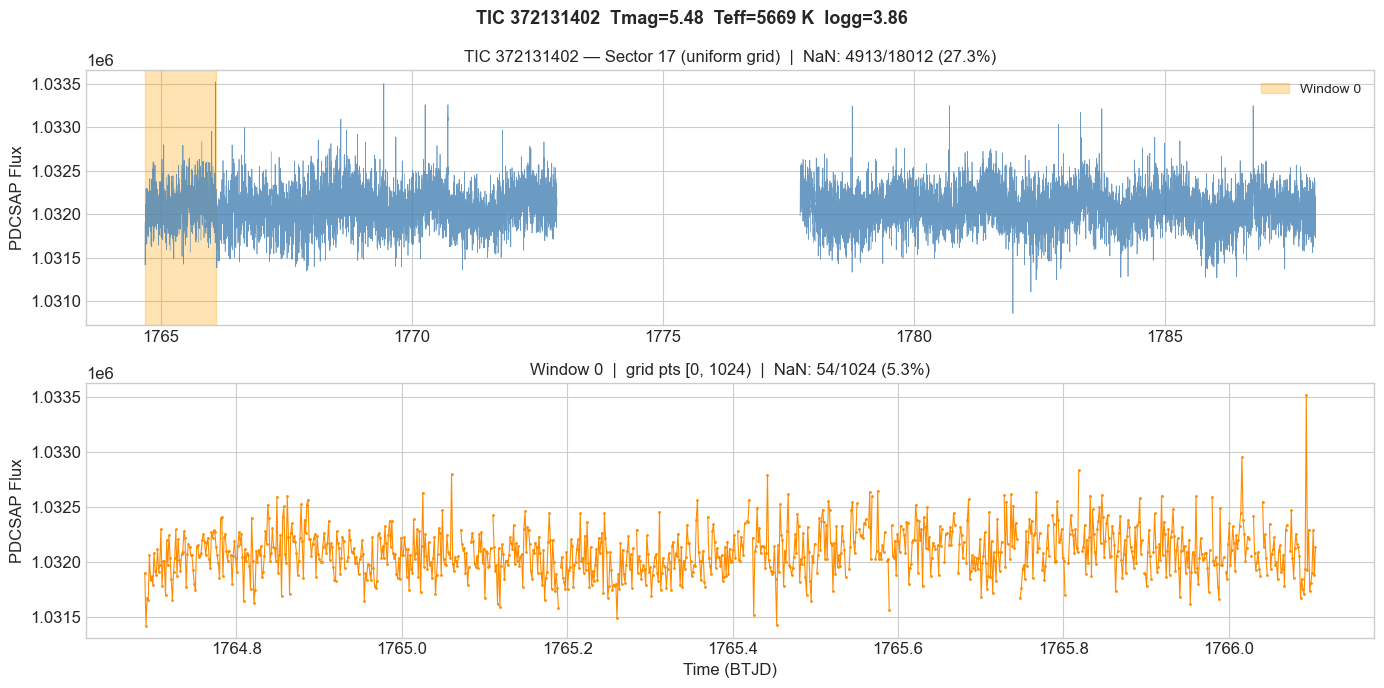

In [14]:
# Example: inspect star 0, sector 0, window 0
plot_window(20, sector_idx=0, window_idx=0)

## Section 3 — TESS 2-min SPOC availability check

Queries MAST for every TIC ID in `df_work` to confirm SPOC 2-min cadence data exists.

Checkpoint: `processed/sector_check_results.csv` (cols: `TIC_ID, n_sectors, sector_list, status`).  
`status ∈ {done, error}` — rerun the cell to resume; `done` rows are skipped, `error` rows are retried.

In [5]:
import threading
import time
import requests
from astroquery.mast import Observations

# ── Constants ──────────────────────────────────────────────────────────────
SECTOR_CHECK_PATH  = PROCESSED / 'sector_check_results.csv'
QUERY_TIMEOUT      = 20    # astroquery socket-level cap (seconds)
THREAD_TIMEOUT     = 25    # belt-and-suspenders thread cap (seconds)
QUERY_DELAY        = 0.5   # politeness sleep between queries (seconds)
CHECKPOINT_EVERY   = 50    # flush CSV every N stars
PROGRESS_EVERY     = 50    # print progress every N stars
MAX_CONSEC_ERRORS  = 500    # abort after this many consecutive errors

Observations.TIMEOUT = QUERY_TIMEOUT

SECTOR_CHECK_COLS = ['TIC_ID', 'n_sectors', 'sector_list', 'status']


# ── Helpers ─────────────────────────────────────────────────────────────────

def _reset_mast_session() -> None:
    """Drop astroquery's HTTP session so dangling connections are closed."""
    try:
        sess = getattr(Observations, '_session', None)
        if sess is not None:
            sess.close()
    except Exception:
        pass
    try:
        Observations._session = requests.Session()
    except Exception:
        pass


def _search_one(tic_id: int) -> tuple[int, list[int], str]:
    """Call lk.search_lightcurve with a thread-level timeout.

    Returns (n_sectors, sector_list, status) where status ∈ {done, error}.
    """
    result: list = [0, [], None]

    def _run() -> None:
        try:
            sr = lk.search_lightcurve(
                f'TIC {tic_id}', mission='TESS', author='SPOC', exptime=120
            )
            n = len(sr)
            try:
                sectors = list(sr.table['sequence_number']) if n > 0 else []
            except Exception:
                sectors = []
            result[0], result[1] = n, sectors
        except Exception as exc:
            result[2] = exc

    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(THREAD_TIMEOUT)

    if t.is_alive():
        _reset_mast_session()
        return 0, [], 'error'
    if result[2] is not None:
        exc = result[2]
        name = type(exc).__name__
        if 'Timeout' in name or 'Connection' in name:
            _reset_mast_session()
        return 0, [], 'error'
    return result[0], result[1], 'done'


def _load_checkpoint(path) -> tuple[list[dict], set[int], set[int]]:
    """Load checkpoint CSV; return (records, done_ids, error_ids)."""
    if not Path(path).exists():
        return [], set(), set()
    df = pd.read_csv(path)
    for col in SECTOR_CHECK_COLS:
        if col not in df.columns:
            df[col] = ''
    records   = df[SECTOR_CHECK_COLS].to_dict('records')
    done_ids  = set(df.loc[df['status'] == 'done',  'TIC_ID'].astype(int))
    error_ids = set(df.loc[df['status'] == 'error', 'TIC_ID'].astype(int))
    return records, done_ids, error_ids


def _flush(records: list[dict], path) -> None:
    pd.DataFrame(records, columns=SECTOR_CHECK_COLS).to_csv(path, index=False)


def run_sector_check(tic_ids: list[int], checkpoint_path) -> pd.DataFrame:
    """Run MAST sector check for all tic_ids with checkpoint/resume.

    Returns the full sector_check DataFrame on completion.
    """
    records, done_ids, error_ids = _load_checkpoint(checkpoint_path)
    rec_index = {int(r['TIC_ID']): i for i, r in enumerate(records)}

    # Skip done; retry errors; process unseen
    skip     = done_ids
    todo     = [t for t in tic_ids if t not in skip]
    # Errors go first so a fresh run quickly confirms the outage is resolved
    todo     = [t for t in todo if t in error_ids] + [t for t in todo if t not in error_ids]

    n_total      = len(tic_ids)
    n_already    = len(done_ids)
    print(f'Total stars: {n_total:,}  |  already done: {n_already:,}  |  to process: {len(todo):,}')
    if not todo:
        print('All stars already checked.')
        return pd.DataFrame(records, columns=SECTOR_CHECK_COLS)

    t0           = time.time()
    consec_err   = 0
    aborted      = False

    try:
        for i, tic_id in enumerate(todo, start=1):
            n_sec, sec_list, status = _search_one(tic_id)

            rec = {
                'TIC_ID':      tic_id,
                'n_sectors':   n_sec,
                'sector_list': ','.join(str(s) for s in sec_list),
                'status':      status,
            }
            if tic_id in rec_index:
                records[rec_index[tic_id]] = rec
            else:
                rec_index[tic_id] = len(records)
                records.append(rec)

            if status == 'done':
                consec_err = 0
            else:
                consec_err += 1

            if i % CHECKPOINT_EVERY == 0 or i == len(todo):
                _flush(records, checkpoint_path)

            if i % PROGRESS_EVERY == 0 or status == 'error' or i == len(todo):
                elapsed  = time.time() - t0
                rate     = i / elapsed if elapsed > 0 else 0
                eta_min  = (len(todo) - i) / rate / 60 if rate > 0 else float('inf')
                n_done   = sum(1 for r in records if r['status'] == 'done')
                n_err    = sum(1 for r in records if r['status'] == 'error')
                n_data   = sum(1 for r in records if r['status'] == 'done' and int(r['n_sectors']) > 0)
                tag      = '  [error]' if status == 'error' else ''
                print(f'  [{n_already + i:>6}/{n_total}]  done={n_done:,}  w/data={n_data:,}  '
                      f'err={n_err:,}  rate={rate:.2f}/s  ETA={eta_min:.1f}min{tag}', flush=True)

            if MAX_CONSEC_ERRORS > 0 and consec_err >= MAX_CONSEC_ERRORS:
                print(f'\n⚠ {consec_err} consecutive errors — MAST may be down. '
                      f'Flushing checkpoint and aborting.\n'
                      f'  Rerun this cell to resume (error rows will be retried first).')
                aborted = True
                break

            time.sleep(QUERY_DELAY)

    except KeyboardInterrupt:
        print('\nInterrupted — flushing checkpoint.')
        aborted = True
    finally:
        _flush(records, checkpoint_path)

    if not aborted:
        n_done = sum(1 for r in records if r['status'] == 'done')
        n_err  = sum(1 for r in records if r['status'] == 'error')
        print(f'\nDone. {n_done:,} checked, {n_err:,} errors. Checkpoint: {checkpoint_path}')

    return pd.DataFrame(records, columns=SECTOR_CHECK_COLS)

In [7]:
df_sectors = run_sector_check(
    tic_ids         = df_work['ID'].astype(int).tolist(),
    checkpoint_path = SECTOR_CHECK_PATH,
)

Total stars: 41,221  |  already done: 41,185  |  to process: 36


No data found for target "TIC 71254533".
No data found for target "TIC 269718144".
No data found for target "TIC 72100249".
No data found for target "TIC 290743237".
No data found for target "TIC 422362973".


  [ 41221/41221]  done=41,221  w/data=34,343  err=0  rate=0.58/s  ETA=0.0min

Done. 41,221 checked, 0 errors. Checkpoint: c:\git_repo\Stellar-World-Model\processed\sector_check_results.csv


## Section 4 — Filter analysis & df_final update

Merge sector-check results into `df_work`, report coverage by Tmag bin, then narrow `df_final` to stars with `n_sectors >= 1`.

In [8]:
# ── Merge sector info into df_work ──────────────────────────────────────────
df_sectors_done = df_sectors[df_sectors['status'] == 'done'].copy()
df_sectors_done['n_sectors'] = pd.to_numeric(df_sectors_done['n_sectors'], errors='coerce').fillna(0).astype(int)

df_merged = df_work.merge(
    df_sectors_done[['TIC_ID', 'n_sectors']],
    left_on='ID', right_on='TIC_ID', how='left',
)
df_merged['n_sectors'] = df_merged['n_sectors'].fillna(-1).astype(int)  # -1 = not yet checked

n_checked  = (df_merged['n_sectors'] >= 0).sum()
n_with_data = (df_merged['n_sectors'] >= 1).sum()
n_no_data   = (df_merged['n_sectors'] == 0).sum()
n_unchecked = (df_merged['n_sectors'] == -1).sum()

print(f'Total stars:      {len(df_merged):,}')
print(f'Checked:          {n_checked:,}')
print(f'  w/ SPOC data:   {n_with_data:,}  ({100*n_with_data/max(n_checked,1):.1f}% of checked)')
print(f'  no SPOC data:   {n_no_data:,}')
print(f'Not yet checked:  {n_unchecked:,}')

# ── Coverage by Tmag bin ─────────────────────────────────────────────────────
bins   = [(None, 7, 'Tmag < 7'), (7, 8, 'Tmag 7-8'), (8, 9, 'Tmag 8-9'), (9, 10, 'Tmag 9-10')]
print(f'\n{"Tmag bin":<14} {"Stars":>8} {"Checked":>9} {"w/data":>9} {"Coverage":>10}')
print('-' * 54)
for lo, hi, label in bins:
    mask = (df_merged['Tmag'] >= (lo if lo is not None else -99)) & (df_merged['Tmag'] < hi)
    sub  = df_merged[mask]
    chk  = (sub['n_sectors'] >= 0).sum()
    wdt  = (sub['n_sectors'] >= 1).sum()
    cov  = f'{100*wdt/max(chk,1):.1f}%' if chk > 0 else 'N/A'
    print(f'{label:<14} {len(sub):>8,} {chk:>9,} {wdt:>9,} {cov:>10}')

# ── Update df_final: only stars with confirmed SPOC data ────────────────────
df_final = df_merged[df_merged['n_sectors'] >= 1][['ID']].copy().reset_index(drop=True)
print(f'\ndf_final updated: {len(df_final):,} stars (n_sectors >= 1)')
if n_unchecked > 0:
    print(f'  [Note] {n_unchecked:,} stars not yet checked — rerun Section 3 to completion for final counts.')

Total stars:      41,221
Checked:          41,221
  w/ SPOC data:   34,343  (83.3% of checked)
  no SPOC data:   6,878
Not yet checked:  0

Tmag bin          Stars   Checked    w/data   Coverage
------------------------------------------------------
Tmag < 7          7,113     7,113     6,654      93.5%
Tmag 7-8          7,747     7,747     6,978      90.1%
Tmag 8-9         11,548    11,548     9,534      82.6%
Tmag 9-10        14,813    14,813    11,177      75.5%

df_final updated: 34,343 stars (n_sectors >= 1)


## Section 5 — Sanity check: dwarf vs evolved star contamination

Gaia BP/RP are absent from the batch CSVs, so `logg` is used as the discriminant.
Note: `logg` null rate is ~57% — classification applies only to stars with available `logg`.

Category               Tmag < 7          Tmag 7-10
--------------------------------------------------
dwarf             3,340 (47.0%)     29,643 (86.9%)
subgiant          1,595 (22.4%)         690 (2.0%)
giant                  0 (0.0%)           0 (0.0%)
unknown           2,178 (30.6%)      3,775 (11.1%)
Total                     7,113             34,108

logg null rate: Tmag<7=30.6%  Tmag7-10=11.1%
  (Classification above is only over stars with logg available)


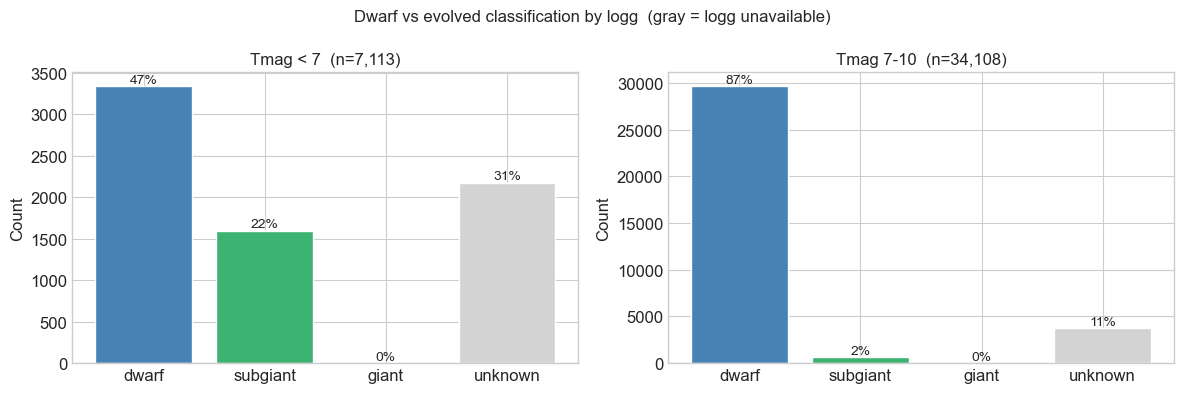

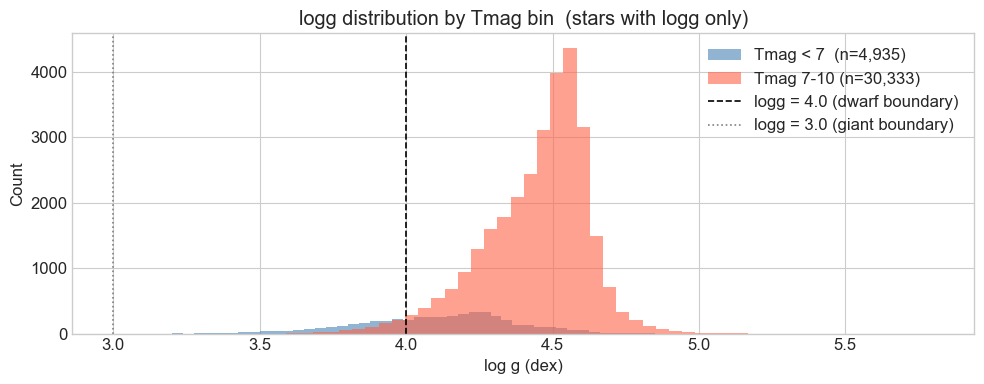

In [9]:
def classify_logg(df: pd.DataFrame) -> pd.Series:
    """Classify stars by logg into dwarf / subgiant / giant / unknown."""
    out = pd.Series('unknown', index=df.index)
    has = df['logg'].notna()
    out[has & (df['logg'] >= 4.0)]                       = 'dwarf'
    out[has & (df['logg'] >= 3.0) & (df['logg'] < 4.0)] = 'subgiant'
    out[has & (df['logg'] < 3.0)]                        = 'giant'
    return out

old = df_work[df_work['Tmag'] < 7].copy()
new = df_work[df_work['Tmag'] >= 7].copy()
old['class'] = classify_logg(old)
new['class'] = classify_logg(new)

cats   = ['dwarf', 'subgiant', 'giant', 'unknown']
colors = ['steelblue', 'mediumseagreen', 'tomato', 'lightgray']

def pct_str(df: pd.DataFrame, cat: str) -> str:
    n   = (df['class'] == cat).sum()
    pct = 100 * n / len(df) if len(df) > 0 else 0
    return f'{n:,} ({pct:.1f}%)'

header = f"{'Category':<12} {'Tmag < 7':>18} {'Tmag 7-10':>18}"
print(header)
print('-' * 50)
for cat in cats:
    print(f'{cat:<12} {pct_str(old, cat):>18} {pct_str(new, cat):>18}')
print(f'{"Total":<12} {len(old):>18,} {len(new):>18,}')
logg_null_old = old['logg'].isna().mean()
logg_null_new = new['logg'].isna().mean()
print(f'\nlogg null rate: Tmag<7={logg_null_old:.1%}  Tmag7-10={logg_null_new:.1%}')
print('  (Classification above is only over stars with logg available)')

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, df_sub, title in zip(axes, [old, new], ['Tmag < 7', 'Tmag 7-10']):
    counts = [(df_sub['class'] == c).sum() for c in cats]
    bars   = ax.bar(cats, counts, color=colors, edgecolor='white')
    ax.set_title(f'{title}  (n={len(df_sub):,})', fontsize=12)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, counts):
        pct = 100 * cnt / len(df_sub) if len(df_sub) else 0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('Dwarf vs evolved classification by logg  (gray = logg unavailable)', fontsize=12)
plt.tight_layout()
plt.show()

# logg histogram overlay
fig, ax = plt.subplots(figsize=(10, 4))
old_logg = old['logg'].dropna()
new_logg = new['logg'].dropna()
ax.hist(old_logg, bins=50, alpha=0.6, color='steelblue', label=f'Tmag < 7  (n={len(old_logg):,})')
ax.hist(new_logg, bins=50, alpha=0.6, color='tomato',    label=f'Tmag 7-10 (n={len(new_logg):,})')
ax.axvline(4.0, color='black', lw=1.2, linestyle='--', label='logg = 4.0 (dwarf boundary)')
ax.axvline(3.0, color='gray',  lw=1.2, linestyle=':',  label='logg = 3.0 (giant boundary)')
ax.set_xlabel('log g (dex)')
ax.set_ylabel('Count')
ax.set_title('logg distribution by Tmag bin  (stars with logg only)')
ax.legend()
plt.tight_layout()
plt.show()

## Section 6 — Export & summary

In [15]:
out_path = PROCESSED / 'df_final.csv'
df_final[['ID']].to_csv(out_path, index=False)
print(f'Exported {len(df_final):,} TIC IDs to {out_path}')
print(f'Columns: {list(df_final.columns)}')

n_after_plx  = (df_raw['plx'] > 10).sum()
df_work_tmag = df_final.merge(df_work[['ID', 'Tmag']], on='ID', how='left')

print('\n========== Cut funnel summary ==========')
print(f'  Raw combined batches:    {len(df_raw):>8,}')
print(f'  After plx > 10 mas:      {n_after_plx:>8,}')
print(f'  After Tmag < 10:         {len(df_work):>8,}')
print(f'  After n_sectors >= 1:    {len(df_final):>8,}  <- df_final')
print(f'    of which Tmag < 7:     {(df_work_tmag["Tmag"] < 7).sum():>8,}')
print(f'    of which Tmag 7-10:    {(df_work_tmag["Tmag"] >= 7).sum():>8,}')
print()
print('Stellar class (stars with logg, pre-SPOC-filter):')
for cat in cats:
    print(f'  {cat:<10} old={pct_str(old, cat):>18}  new={pct_str(new, cat):>18}')

Exported 34,343 TIC IDs to c:\git_repo\Stellar-World-Model\processed\df_final.csv
Columns: ['ID']

========== Cut funnel summary ==========
  Raw combined batches:     594,689
  After plx > 10 mas:        41,222
  After Tmag < 10:           41,221
  After n_sectors >= 1:      34,343  <- df_final
    of which Tmag < 7:        6,654
    of which Tmag 7-10:      27,689

Stellar class (stars with logg, pre-SPOC-filter):
  dwarf      old=     3,340 (47.0%)  new=    29,643 (86.9%)
  subgiant   old=     1,595 (22.4%)  new=        690 (2.0%)
  giant      old=          0 (0.0%)  new=          0 (0.0%)
  unknown    old=     2,178 (30.6%)  new=     3,775 (11.1%)
